# Library Installations

In [ ]:
# !pip install python-lorem

In [ ]:
# !apt install libgraphviz-dev
# !pip install pygraphviz

In [ ]:
# !apt-get install graphviz
# !pip install graphviz

# Google Colab Specific Setup

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive/')

# Imports

In [ ]:
# import lorem
# import random

# from pathlib     import Path
# from collections import Counter

# from datetime import date
# from datetime import time
# from datetime import datetime

# Problem

# 42 Trapping Rain Water

Given `n` non-negative integers representing an elevation map where the width of each bar is `1`, compute how much water it can trap after raining.

# Examples

**Example 1:**

```
height = [0,1,0,2,1,0,1,3,2,1,2,1]
```
Output:
```
6
```
Explanation  
The above elevation map (black section) is represented by array `[0,1,0,2,1,0,1,3,2,1,2,1]`. In this case, `6` units of rain water (blue section) are being trapped.
  


**Example 2:**

Input:
```
height = [4,2,0,3,2,5]
```
Output:
```
9
```


# Constraints


    n == height.length
    1 <= n <= 2 * 104
    0 <= height[i] <= 105


# Solution

In [65]:
import random
from random import choice
from typing import List, Tuple, Optional, Union

import pandas as pd

In [2]:
height = [0,1,0,2,1,0,1,3,2,1,2,1]

In [100]:
height = [random.randint(0, 7) for _ in range(10)]

In [101]:
height

[0, 4, 3, 5, 7, 5, 2, 3, 5, 2]

In [104]:
sorted(enumerate(height), key=lambda x: x[1], reverse=True)

[(4, 7),
 (3, 5),
 (5, 5),
 (8, 5),
 (1, 4),
 (2, 3),
 (7, 3),
 (6, 2),
 (9, 2),
 (0, 0)]

1. Find maximum
    1. If there's more than one maximum, water will get filled in between.
2. Find next maximum on each side.
    1. Water will get filled to a level of next maximum


1. find_indices_of_maximum(start, end) -> List[int]
    1. If there's a single element
    2. If there are two elements
    3. If there are more than two elements


2. If there's a single element,
1. get indices of second maximum on the left and right.


In [48]:
# def fill_water_between_maximums(indices_of_maximum, height, case):

#     if case == 2:

#         start_index = indices_of_maximum[0][0]
#         end_index   = indices_of_maximum[1][0]

#         current_max = indices_of_maximum[0][1]

#         print(f"{start_index=}")
#         print(f"{end_index=}")

#         filled_water_volume = 0

#         for i, x in enumerate(height[start_index + 1: end_index]):

#             iteration_extra_water = current_max - x

#             print(f"{iteration_extra_water=}")

#             filled_water_volume += iteration_extra_water



#     return filled_water_volume

In [ ]:

# def fill_water_between_top_two_maximums(indices_of_maximum, height, case):

#     filled_water_volume = 0

#     if case == 2:

#         start_index = indices_of_maximum[0][0]
#         end_index   = indices_of_maximum[1][0]

#         current_max = indices_of_maximum[0][1]

#         print(f"{start_index=}")
#         print(f"{end_index=}")


#         for i, x in enumerate(height[start_index + 1: end_index]):

#             iteration_extra_water = current_max - x

#             print(f"{iteration_extra_water=}")

#             filled_water_volume += iteration_extra_water

#     return filled_water_volume

In [43]:
# def get_indices_of_maximum(sorted_list, start_index, end_index):

#     new_list = [(index, value) for (index, value) in sorted_list if (index <= end_index) and (index >= start_index)]
#     max_element = new_list[0][1]
#     list_of_maximums = [(index, value) for (index, value) in sorted_list if (max_element == value)]

#     return list_of_maximums

## Pseudocode

1. Convert height into a sorted array where indices are mentioned.
2. Take the top two elements of this list.
3. Fill water between them.
4. Run loops on the left and right:
    1. till there are elements on the left:
        1. take an element to the left and fill water
    1. till there are elements on the right:
        1. take an element to the right and fill water

In [121]:
def convert_array_into_index_max_format(input_height_array: List[int]) -> List[Tuple[int, int]]:

    return sorted(enumerate(input_height_array), key=lambda x: x[1], reverse=True)

def get_indices_of_top_two_maximums(sorted_list, start_index, end_index):

    new_list = [(index, value) for (index, value) in sorted_list if (index <= end_index) and (index >= start_index)]

    if len(new_list) >= 2:

        max_element      = new_list[0][1]
        next_max_element = new_list[1][1]

        max_index        = new_list[0][0]
        next_max_index   = new_list[1][0]

        if max_index <= next_max_index:
            start_index = max_index
            end_index   = next_max_index
        else:
            start_index = next_max_index
            end_index   = max_index

        print(f"{max_element=}")
        print(f"{next_max_element=}")

        print(f"{max_index=}")
        print(f"{next_max_index=}")

        print(f"{start_index=}")
        print(f"{end_index=}")

        return max_element, next_max_element, start_index, end_index
    else:
        return None, None, None, None


def fill_water_between_two_maximums(start_index, end_index, smaller_element, height):

    filled_water_volume = 0

    print(f"{start_index=}")
    print(f"{end_index=}")

    for i, x in enumerate(height[start_index + 1: end_index]):

        iteration_extra_water = smaller_element - x

        print(f"{iteration_extra_water=}")

        filled_water_volume += iteration_extra_water

    return filled_water_volume


def get_max_element_in_right_array(end_index, height, sorted_formatted_array):

    new_list = [(index, value) for (index, value) in sorted_formatted_array if (index > end_index)]

    if len(new_list) > 0:
        return new_list[0]
    else:
        return None, None

def get_max_element_in_left_array(start_index, height, sorted_formatted_array):

    new_list = [(index, value) for (index, value) in sorted_formatted_array if (index < start_index)]

    if len(new_list) > 0:
        return new_list[0]
    else:
        return None, None


In [141]:
sorted_formatted_array = convert_array_into_index_max_format(height)

(
    max_element,
    next_max_element,
    start_index,
    end_index
) = get_indices_of_top_two_maximums(sorted_formatted_array,
                                    0,
                                    len(height) - 1
                                    )

filled_water_volume = fill_water_between_two_maximums(
    start_index,
    end_index,
    next_max_element,
    height
)


current_right_index = end_index
filled_water_volume_right = 0


current_left_index = start_index
filled_water_volume_left = 0



max_element=7
next_max_element=5
max_index=4
next_max_index=3
start_index=3
end_index=4
start_index=3
end_index=4


<Axes: >

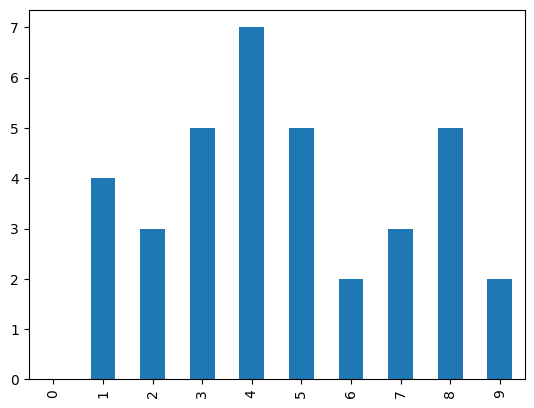

In [142]:
h_df.plot(kind="bar")

In [143]:
print(f"{sorted_formatted_array=}")
print(f"{current_right_index=}")
print(f"{next_max_element=}")
print(f"{filled_water_volume=}")
print(f"{left_index=}")
print(f"{left_value=}")
print(f"{filled_water_volume_right=}")
print(f"{filled_water_volume_left=}")

sorted_formatted_array=[(4, 7), (3, 5), (5, 5), (8, 5), (1, 4), (2, 3), (7, 3), (6, 2), (9, 2), (0, 0)]
current_right_index=4
next_max_element=5
filled_water_volume=0
left_index=1
left_value=0
filled_water_volume_right=0
filled_water_volume_left=0


In [144]:

while current_left_index > 0:

    new_left_index, left_value = get_max_element_in_left_array(current_left_index, height, sorted_formatted_array)

    print(f"{new_left_index=}")
    print(f"{left_value=}")

    if current_left_index is None:
        break
    if new_left_index is None:
        break

    filled_water_volume_left_new = fill_water_between_two_maximums(
        new_left_index,
        current_left_index,
        left_value,
        height
    )

    filled_water_volume_left += filled_water_volume_left_new

    current_left_index = new_left_index

    print(f"{filled_water_volume_left=}")

new_left_index=1
left_value=4
start_index=1
end_index=3
iteration_extra_water=1
filled_water_volume_left=1
new_left_index=0
left_value=0
start_index=0
end_index=1
filled_water_volume_left=1


In [145]:

while current_right_index <= (len(height) - 1):


    new_right_index, right_value = get_max_element_in_right_array(current_right_index, height, sorted_formatted_array)

    print(f"{new_right_index=}")
    print(f"{right_value=}")

    if current_right_index is None:
        break
    if new_right_index is None:
        break

    filled_water_volume_right_new = fill_water_between_two_maximums(
        current_right_index,
        new_right_index,
        right_value,
        height
    )

    filled_water_volume_right += filled_water_volume_right_new

    current_right_index = new_right_index

    print(f"{filled_water_volume_right=}")

new_right_index=5
right_value=5
start_index=4
end_index=5
filled_water_volume_right=0
new_right_index=8
right_value=5
start_index=5
end_index=8
iteration_extra_water=3
iteration_extra_water=2
filled_water_volume_right=5
new_right_index=9
right_value=2
start_index=8
end_index=9
filled_water_volume_right=5
new_right_index=None
right_value=None


In [146]:
total_filled_water = filled_water_volume + filled_water_volume_left + filled_water_volume_right

In [147]:

print(f"{total_filled_water=}")

total_filled_water=6


# All code

In [150]:
def get_filled_water_volume(height):

    def convert_array_into_index_max_format(input_height_array: List[int]) -> List[Tuple[int, int]]:

        return sorted(enumerate(input_height_array), key=lambda x: x[1], reverse=True)

    def get_indices_of_top_two_maximums(sorted_list, start_index, end_index):

        new_list = [(index, value) for (index, value) in sorted_list if (index <= end_index) and (index >= start_index)]

        if len(new_list) >= 2:

            max_element      = new_list[0][1]
            next_max_element = new_list[1][1]

            max_index        = new_list[0][0]
            next_max_index   = new_list[1][0]

            if max_index <= next_max_index:
                start_index = max_index
                end_index   = next_max_index
            else:
                start_index = next_max_index
                end_index   = max_index

            print(f"{max_element=}")
            print(f"{next_max_element=}")

            print(f"{max_index=}")
            print(f"{next_max_index=}")

            print(f"{start_index=}")
            print(f"{end_index=}")

            return max_element, next_max_element, start_index, end_index
        else:
            return None, None, None, None


    def fill_water_between_two_maximums(start_index, end_index, smaller_element, height):

        filled_water_volume = 0

        print(f"{start_index=}")
        print(f"{end_index=}")

        for i, x in enumerate(height[start_index + 1: end_index]):

            iteration_extra_water = smaller_element - x

            print(f"{iteration_extra_water=}")

            filled_water_volume += iteration_extra_water

        return filled_water_volume


    def get_max_element_in_right_array(end_index, height, sorted_formatted_array):

        new_list = [(index, value) for (index, value) in sorted_formatted_array if (index > end_index)]

        if len(new_list) > 0:
            return new_list[0]
        else:
            return None, None

    def get_max_element_in_left_array(start_index, height, sorted_formatted_array):

        new_list = [(index, value) for (index, value) in sorted_formatted_array if (index < start_index)]

        if len(new_list) > 0:
            return new_list[0]
        else:
            return None, None



    sorted_formatted_array = convert_array_into_index_max_format(height)

    (
        max_element,
        next_max_element,
        start_index,
        end_index
    ) = get_indices_of_top_two_maximums(sorted_formatted_array,
                                        0,
                                        len(height) - 1
                                        )

    filled_water_volume = fill_water_between_two_maximums(
        start_index,
        end_index,
        next_max_element,
        height
    )


    current_right_index = end_index
    filled_water_volume_right = 0


    current_left_index = start_index
    filled_water_volume_left = 0





    while current_left_index > 0:

        new_left_index, left_value = get_max_element_in_left_array(current_left_index, height, sorted_formatted_array)

        print(f"{new_left_index=}")
        print(f"{left_value=}")

        if current_left_index is None:
            break
        if new_left_index is None:
            break

        filled_water_volume_left_new = fill_water_between_two_maximums(
            new_left_index,
            current_left_index,
            left_value,
            height
        )

        filled_water_volume_left += filled_water_volume_left_new

        current_left_index = new_left_index

        print(f"{filled_water_volume_left=}")


    while current_right_index <= (len(height) - 1):

        new_right_index, right_value = get_max_element_in_right_array(current_right_index, height, sorted_formatted_array)

        print(f"{new_right_index=}")
        print(f"{right_value=}")

        if current_right_index is None:
            break
        if new_right_index is None:
            break

        filled_water_volume_right_new = fill_water_between_two_maximums(
            current_right_index,
            new_right_index,
            right_value,
            height
        )

        filled_water_volume_right += filled_water_volume_right_new

        current_right_index = new_right_index

        print(f"{filled_water_volume_right=}")


    total_filled_water = filled_water_volume + filled_water_volume_left + filled_water_volume_right

    print(f"{total_filled_water=}")

    return total_filled_water



In [152]:
height = [random.randint(0, 7) for _ in range(10)]
print(f"{height=}")


height=[4, 2, 1, 1, 6, 4, 2, 2, 3, 7]


In [153]:
filled_water = get_filled_water_volume(height)
print(f"{filled_water=}")

max_element=7
next_max_element=6
max_index=9
next_max_index=4
start_index=4
end_index=9
start_index=4
end_index=9
iteration_extra_water=2
iteration_extra_water=4
iteration_extra_water=4
iteration_extra_water=3
new_left_index=0
left_value=4
start_index=0
end_index=4
iteration_extra_water=2
iteration_extra_water=3
iteration_extra_water=3
filled_water_volume_left=8
new_right_index=None
right_value=None
total_filled_water=21
filled_water=21


In [154]:
def plot_height_array(height):

    h_df = pd.Series(height)

    h_df.plot(kind="bar")

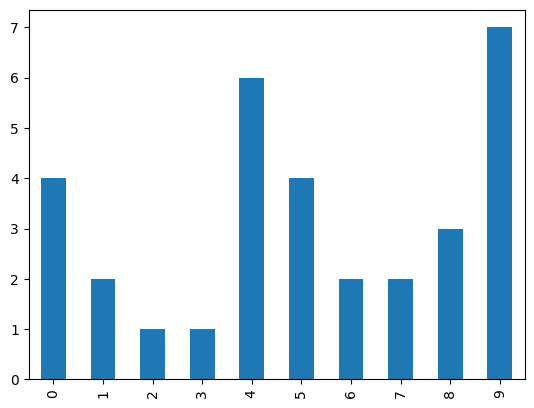

In [155]:
plot_height_array(height)

In [130]:

left_index,  left_value  = get_max_element_in_left_array(start_index, height, sorted_formatted_array)

# fill left
filled_water_volume_left = fill_water_between_two_maximums(
    left_index,
    start_index,
    left_value,
    height
)

start_index=1
end_index=3
iteration_extra_water=1


In [107]:
print(f"{sorted_formatted_array=}")
print(f"{max_element=}")
print(f"{next_max_element=}")
print(f"{filled_water_volume=}")
print(f"{right_index=}")
print(f"{right_value=}")
print(f"{left_index=}")
print(f"{left_value=}")
print(f"{filled_water_volume_right=}")
print(f"{filled_water_volume_left=}")

sorted_formatted_array=[(4, 7), (3, 5), (5, 5), (8, 5), (1, 4), (2, 3), (7, 3), (6, 2), (9, 2), (0, 0)]
max_element=7
next_max_element=5
filled_water_volume=0
right_index=5
right_value=5
left_index=1
left_value=4
filled_water_volume_right=0
filled_water_volume_left=1


In [55]:
sorted_list_with_indices = sorted(enumerate(height), key=lambda x: x[1], reverse=True)

indices_of_maximum = get_indices_of_maximum(sorted_list_with_indices, 0, len(height) - 1)
print(indices_of_maximum)

[(16, 5), (17, 5)]


In [56]:
if len(indices_of_maximum) == 2:
    filled_water_volume = fill_water_between_topmaximums(indices_of_maximum=indices_of_maximum, height=height, case=2)
    print(filled_water_volume)

    fill_left_of_maximum()
    fill_right_of_maximum()

start_index=16
end_index=17
0


In [ ]:
def get_random_words():

    number_of_words     = random.randint(1, 20)

    complete_string_list = []

    for x in range(number_of_words):

        random_word = get_random_lower_case_word(20)

        complete_string_list.append(random_word)


    return complete_string_list

In [ ]:
random_word_string = get_random_words()

In [ ]:
random_word_string

['abcdrigvnydudsompmae',
 'abcdtdugujlkgdjxyefl',
 'abcdejsyrbfzb',
 'abcdbbzpoiwzlwqytb',
 'abcdqbrjavgwrrvzilrrwedq',
 'abcdhmitlrddzkbijctxmlfa',
 'abcdbvnzfimykl',
 'abcdt',
 'abcdshvote',
 'abcdccccbsmcxiwouwmxbada']

In [ ]:
from typing import List
import pdb
class Solution:
    def longestCommonPrefix(self, strs: List[str]) -> str:

        longest_common_prefix   = []
        current_char_to_compare = ""
        current_index           = -1
        exit_loop               = 0

        # pdb.set_trace()
        if len(strs) > 0:
            while (exit_loop < 1):
                current_index += 1
                if (current_index <= (len(strs[0]) - 1)):
                    current_char_to_compare = strs[0][current_index]
                else:
                    exit_loop = 1

                exit_for_loop = 0
                for str in strs[1:]:
                    if (current_index > (len(str) - 1)) or (str[current_index] != current_char_to_compare):
                        exit_for_loop = 1

                if (exit_for_loop == 0) and ((exit_loop == 0)):
                    longest_common_prefix.append(current_char_to_compare)
                else:
                    exit_loop = 1


        return "".join(longest_common_prefix)


In [ ]:
solution_object = Solution()
string_outputs      = solution_object.longestCommonPrefix(random_word_string)
# string_outputs      = solution_object.longestCommonPrefix(["a"])

print(f"{string_outputs=}")



string_outputs='abcd'


In [ ]:
random_word_string

['abcdrigvnydudsompmae',
 'abcdtdugujlkgdjxyefl',
 'abcdejsyrbfzb',
 'abcdbbzpoiwzlwqytb',
 'abcdqbrjavgwrrvzilrrwedq',
 'abcdhmitlrddzkbijctxmlfa',
 'abcdbvnzfimykl',
 'abcdt',
 'abcdshvote',
 'abcdccccbsmcxiwouwmxbada']

In [ ]:
from typing import List
import pdb
class Solution:
    def longestCommonPrefix(self, strs: List[str]) -> str:

        longest_common_prefix   = []
        current_char_to_compare = ""
        current_index           = -1
        exit_loop               = 0

        # pdb.set_trace()
        if len(strs) > 0:
            while (exit_loop < 1):
                current_index += 1
                if (current_index <= (len(strs[0]) - 1)):
                    current_char_to_compare = strs[0][current_index]
                else:
                    exit_loop = 1

                exit_for_loop = 0
                for str in strs[1:]:
                    if (current_index > (len(str) - 1)) or (str[current_index] != current_char_to_compare):
                        exit_for_loop = 1
                        break

                if (exit_for_loop == 0) and ((exit_loop == 0)):
                    longest_common_prefix.append(current_char_to_compare)
                else:
                    exit_loop = 1


        return "".join(longest_common_prefix)


In [ ]:
solution_object = Solution()
string_outputs      = solution_object.longestCommonPrefix(random_word_string)
# string_outputs      = solution_object.longestCommonPrefix(["a"])

print(f"{string_outputs=}")



string_outputs='abcd'
